# Remaining Useful Life Prediction - Self-Supervised Autoencoder Pretraining #

**Topic:** Uncertainty-Aware and Explainable Deep Learning Framework for Remaining Useful Life Prediction in Smart Manufacturing Systems

**Stage:** Self-Supervised Pretraining, learning normal machine behavior from unlabeled time-series data


---

### OVERVIEW

| Step | Description |
|------|-------------|
| 1 | Install and import dependencies |
| 2 | Download and explore the C-MAPSS (CMAPSS) dataset |
| 3 | Data preparation — normalisation and sliding windows |
| 4 | Build the LSTM Autoencoder architecture |
| 5 | Self-supervised pretraining (reconstruction objective) |
| 6 | Evaluate reconstruction quality and anomaly thresholding |
| 7 | Extract and save pretrained encoder weights for Part 2 |

---

> **Dataset used:** NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) — FD001 subset.  
> [Dataset link](https://www.kaggle.com/datasets/behrad3d/nasa-cmaps)


## Step 1: Install and Import Dependencies ##

In [ ]:
!pip install -q kagglehub scikit-learn matplotlib seaborn tqdm

In [ ]:
import zipfile
import os
from google.colab import files
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub
import pickle
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.manifold import TSNE

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

sns.set_theme(style = "darkgrid", palette = "muted")
plt.rcParams["figure.dpi"] = 110

Using device: cuda


## Step 2: Download and Explore the C-MAPSS Dataset ##

The Nasa C-MAPSS FD001 dataset simulates a turbofan engine degradation process.
* 21 sensor readings per time-step (e.g. temperature, pressure, fan speed, etc.)
* 3 operational settings per time-step
* 100 training engines, each run-to-failure

All data before the final failure point represents normal-to-degraded operation, so it's useful for self-supervised pretraining on normal behavior.

In [ ]:
uploaded = files.upload()

Saving CMAPSSData.zip to CMAPSSData.zip


In [ ]:
ZIP_PATH = "/content/CMAPSSData.zip"
EXTRACT_PATH = "data"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
  zip_ref.extractall(EXTRACT_PATH)

print("Unzipped to: ", EXTRACT_PATH)

Unzipped to:  data


In [ ]:
INDEX_COLS = ["unit_id", "cycle"]
SETTING_COLS = ["setting_1", "setting_2", "setting_3"]
SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_COLS

def load_cmapss(data_dir, subset = "FD001"):
  """
  Loads training split of a C-MAPSS subset.
  """

  candidates = [
      os.path.join(data_dir, f"train_{subset}.txt"),
      os.path.join(data_dir, "CMAPSSData", f"train_{subset}.txt")
  ]

  path = next((p for p in candidates if os.path.exists(p)), None)
  if path is None:
    raise FileNotFoundError(
        f"Could not find train_{subset}.txt under {data_dir}."
        "Please follow Option B/C in the cell above."
    )

  df = pd.read_csv(path, sep = r"\s+", header = None, names = ALL_COLS)
  print(f"Loaded {subset}: {df.shape[0]:,} rows, {df["unit_id"].nunique()} engines")

  return df

DATA_DIR = EXTRACT_PATH
df_raw = load_cmapss(DATA_DIR, subset = "FD001")
df_raw.head()

Loaded FD001: 20,631 rows, 100 engines


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


==========  Dataset Information  ==========
                  mean           std        min        max
unit_id      51.506568  2.922763e+01     1.0000   100.0000
cycle       108.807862  6.888099e+01     1.0000   362.0000
setting_1    -0.000009  2.187313e-03    -0.0087     0.0087
setting_2     0.000002  2.930621e-04    -0.0006     0.0006
setting_3   100.000000  0.000000e+00   100.0000   100.0000
sensor_1    518.670000  6.537152e-11   518.6700   518.6700
sensor_2    642.680934  5.000533e-01   641.2100   644.5300
sensor_3   1590.523119  6.131150e+00  1571.0400  1616.9100
sensor_4   1408.933782  9.000605e+00  1382.2500  1441.4900
sensor_5     14.620000  3.394700e-12    14.6200    14.6200
sensor_6     21.609803  1.388985e-03    21.6000    21.6100
sensor_7    553.367711  8.850923e-01   549.8500   556.0600
sensor_8   2388.096652  7.098548e-02  2387.9000  2388.5600
sensor_9   9065.242941  2.208288e+01  9021.7300  9244.5900
sensor_10     1.300000  4.660829e-13     1.3000     1.3000
sensor_11   

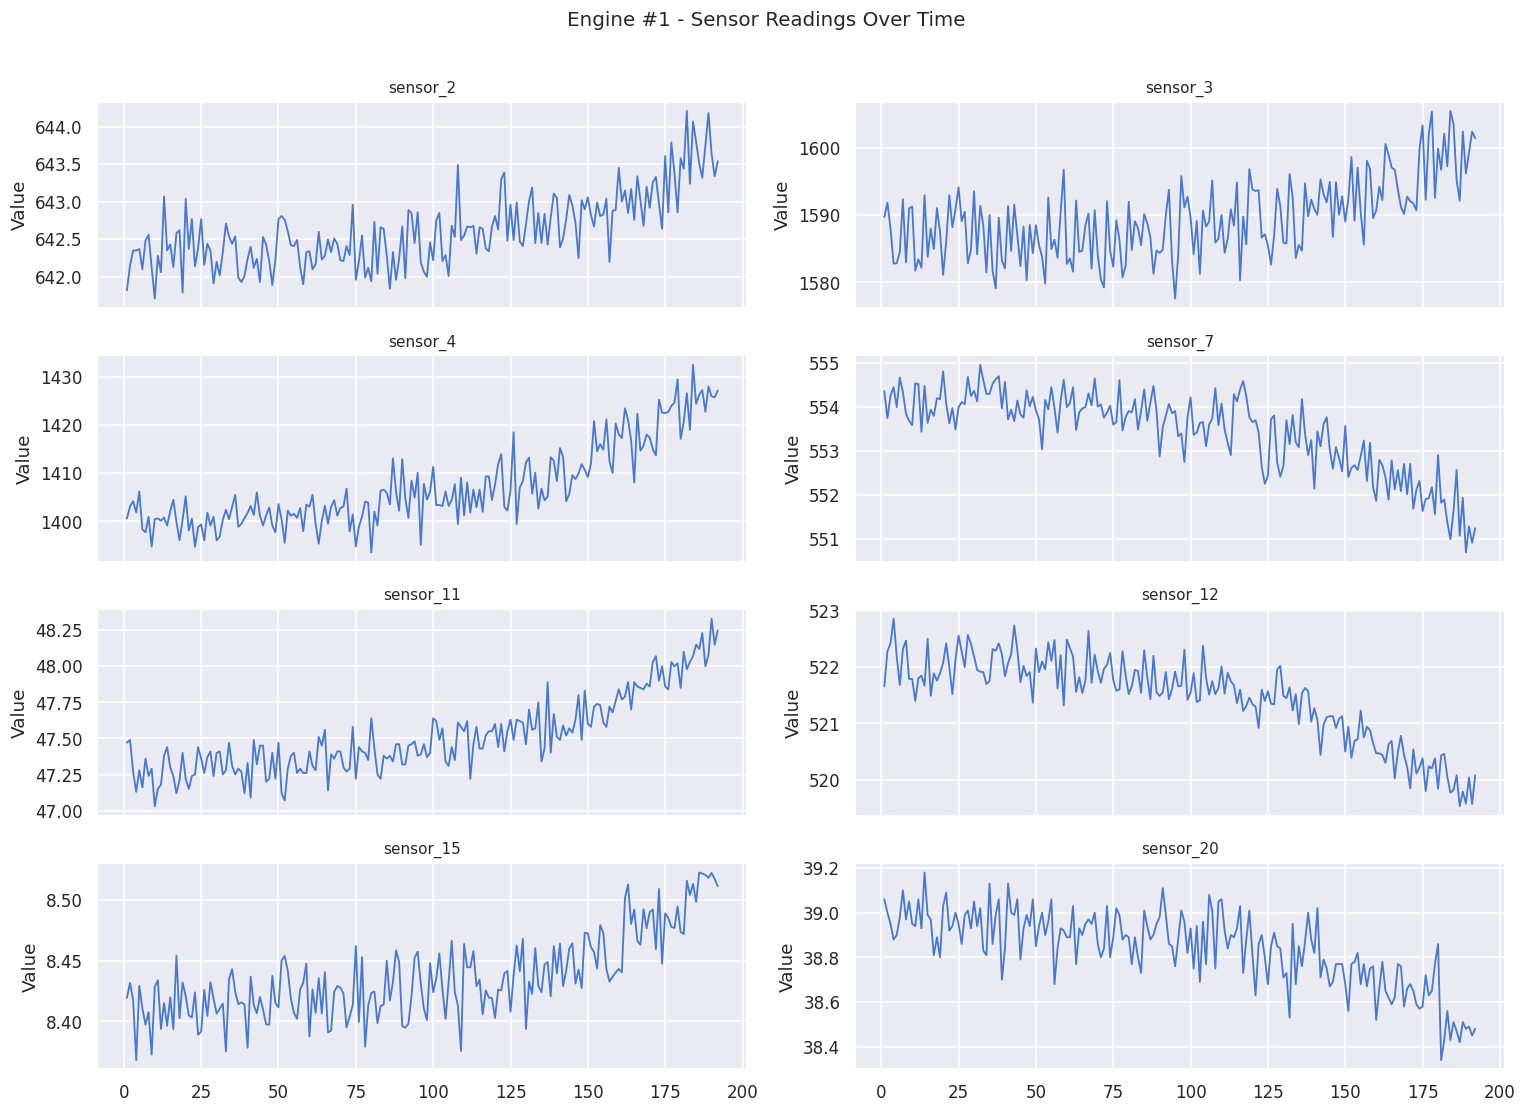

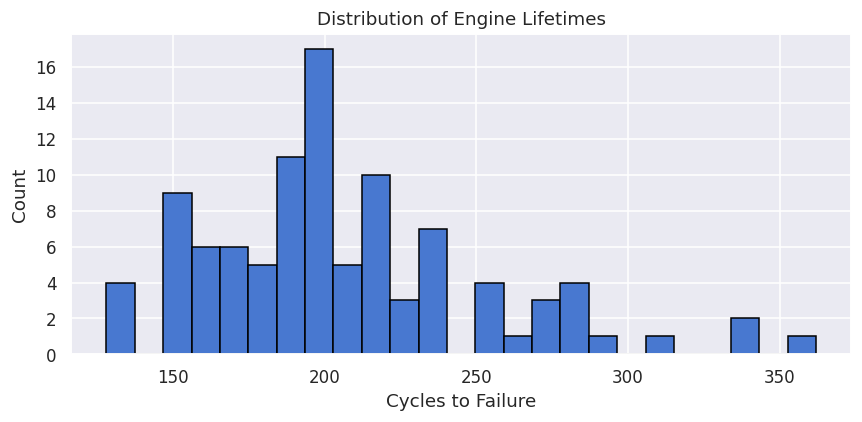

Median lifetime: 199 cycles | Max: 362 | Min: 128


In [ ]:
print("=" * 10, " Dataset Information ", "=" * 10)
print(df_raw.describe().T[["mean", "std", "min", "max"]].to_string())

# Plot sensor signals for one engine
engine_id = 1
engine_df = df_raw[df_raw["unit_id"] == engine_id]

sensors_to_plot = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_11", "sensor_12", "sensor_15", "sensor_20"]

fig, axes = plt.subplots(4, 2, figsize = (14, 10), sharex = True)
axes = axes.flatten()
for ax, col in zip(axes, sensors_to_plot):
  ax.plot(engine_df["cycle"], engine_df[col], linewidth = 1.2)
  ax.set_title(col, fontsize = 10)
  ax.set_ylabel("Value")
fig.suptitle(f"Engine #{engine_id} - Sensor Readings Over Time", fontsize = 13, y = 1.01)
plt.tight_layout()
plt.show()

# Distribution of engine lifetimes
lifetimes = df_raw.groupby("unit_id")["cycle"].max()
fig, ax = plt.subplots(figsize = (8, 4))
ax.hist(lifetimes, bins = 25, edgecolor = "black")
ax.set(title = "Distribution of Engine Lifetimes", xlabel = "Cycles to Failure", ylabel = "Count")
plt.tight_layout()
plt.show()

print(f"Median lifetime: {lifetimes.median():.0f} cycles | Max: {lifetimes.max()} | Min: {lifetimes.min()}")

## Step 3: Data Preparation ##

### Strategy for Self-Supervised Pretraining

The autoencoder is only trained on the early (healthy) portion of each engine's life (first 30% of cycles). This allows it to reconstruct the normal operation, and during inference, high reconstruction error signals anomalous / degraded behavior.

Steps:
1. Drop sensors with near-zero variance (uninformative)
2. Min-Max normalize all feature columns
3. Extract healthy windows via sliding windows
4. Construct a `TensorDataset` for PyTorch

In [ ]:
# Drop near-zero variance sensors
VARIANCE_THRESHOLD = 3e-3

ALL_CANDIDATES = SETTING_COLS + SENSOR_COLS
all_stds = df_raw[ALL_CANDIDATES].std()
low_var = all_stds[all_stds < VARIANCE_THRESHOLD].index.tolist()
print(f"Dropping {len(low_var)} low-variance features: {low_var}")

FEATURE_COLS = [f for f in ALL_CANDIDATES if f not in low_var]
print(f"Using {len(FEATURE_COLS)} feature columns: {FEATURE_COLS}")

Dropping 10 low-variance features: ['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Using 14 feature columns: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [ ]:
scaler = MinMaxScaler()

HEALTHY_FRAC = 0.4 # Use first 40% of engine's life for pretraining
healthy_mask = df_raw.groupby("unit_id")["cycle"].transform(lambda s: s <= (s.max() * HEALTHY_FRAC))

df_healthy_only = df_raw[healthy_mask]
scaler.fit(df_healthy_only[FEATURE_COLS])

df_scaled = df_raw.copy()
df_scaled[FEATURE_COLS] = scaler.transform(df_raw[FEATURE_COLS])

with open('/content/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved to /content/scaler.pkl')

Scaler saved to /content/scaler.pkl


In [ ]:
def make_windows(df, feature_cols, window_size, stride, healthy_frac):
  """
  Extracts overlapping windows of shape (window_size, n_features) from the
  healthy fraction of cycles per engine.
  """

  windows = []
  for uid, grp in df.groupby("unit_id"):
    grp = grp.sort_values("cycle").reset_index(drop = True)
    max_cycle = grp["cycle"].max()
    cutoff = int(max_cycle * healthy_frac)
    healthy_grp = grp[grp["cycle"] <= cutoff]
    data = healthy_grp[feature_cols].values.astype(np.float32)

    for start in range(0, len(data) - window_size + 1, stride):
      windows.append(data[start:start + window_size])

  return np.stack(windows, axis = 0)

Total windows: 5,316 | Shape: (5316, 30, 14)


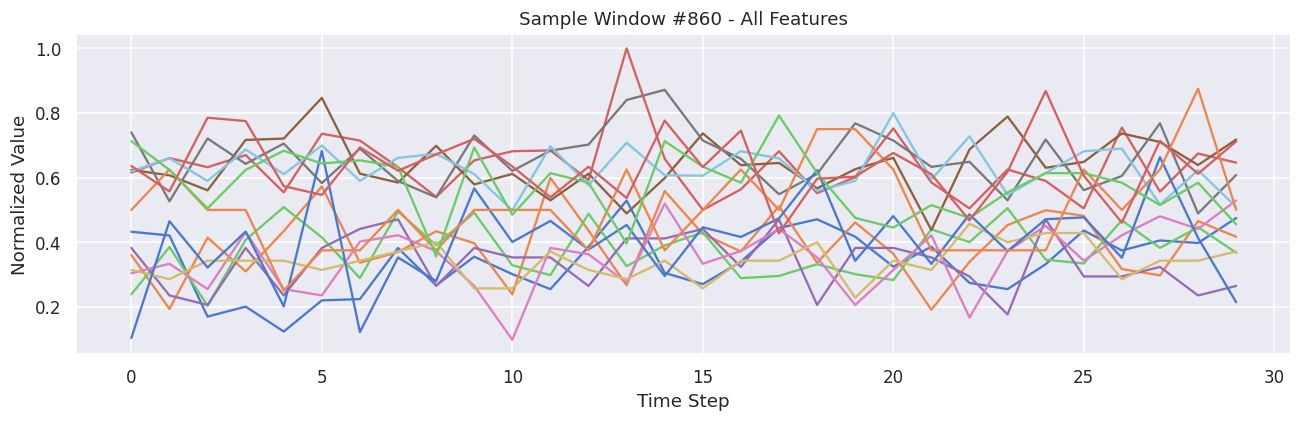

In [ ]:
# Hyperparameters for sliding window
WINDOW_SIZE = 30 # time-steps per sequence
STRIDE = 1 # sliding window step
BATCH_SIZE = 128
VAL_SPLIT = 0.15 # 15% of windows held out for validation

windows = make_windows(df_scaled, FEATURE_COLS, WINDOW_SIZE, STRIDE, HEALTHY_FRAC)
print(f"Total windows: {len(windows):,} | Shape: {windows.shape}")

plt.figure(figsize = (12, 4))
idx = np.random.randint(len(windows))
plt.plot(windows[idx])
plt.title(f"Sample Window #{idx} - All Features")
plt.xlabel("Time Step")
plt.ylabel("Normalized Value")
plt.tight_layout()
plt.show()

In [ ]:
class WindowDataset(Dataset):
  """
  Wraps a NumPy array of windows for unsupervised autoencoder training.
  """

  def __init__(self, data: np.ndarray):
    self.data = torch.tensor(data, dtype = torch.float32)

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    return self.data[idx]

full_dataset = WindowDataset(windows)
n_val = int(len(full_dataset) * VAL_SPLIT)
n_train = len(full_dataset) - n_val

train_dataset, val_dataset = random_split(full_dataset, [n_train, n_val], generator = torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 2, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 2, pin_memory = True)

print(f"Train windows: {n_train:,} | Val windows: {n_val:,}")
print(f"Input shape per batch: {next(iter(train_loader)).shape}")

Train windows: 4,519 | Val windows: 797
Input shape per batch: torch.Size([128, 30, 14])


## Step 4: LSTM Autoencoder Architecture ##

Autoencoders can be implemented using LSTMs. In this case, the encoder module is an LSTM and the decoder module is another LSTM.

The hidden dimensionality is the size of the state vector (hidden state) and the cell state (long-term memory).

The latent dimensionality is the size of the learned representation used to encode the input. In this case, it's the size of the bottleneck.

```
Input (batch, seq_len, n_features)
  │
  ▼
┌──────────────────────────────────────────┐
│  ENCODER                                 │
│  LSTM Layer 1 -> hidden_dim              │
│  LSTM Layer 2 -> latent_dim (bottleneck) │
└──────────────────────────────────────────┘
  │  latent vector (batch, latent_dim)
  ▼
┌──────────────────────────────────────────┐
│  DECODER                                 │
│  RepeatVector -> (batch, seq_len, latent)│
│  LSTM Layer 1 -> hidden_dim              │
│  LSTM Layer 2 -> n_features              │
│  Linear output -> n_features             │
└──────────────────────────────────────────┘
  │
  ▼
Output (batch, seq_len, n_features)
```

The bottleneck between encoder and decoder forces the model to learn a compact representation of normal machine behavior. The output is a reconstruction of the input.

In [ ]:
class LSTMEncoder(nn.Module):
  """
  Two-layer bidirectional LSTM encoder. Returns the hidden state of the second LSTM as the
  latent vector.
  """

  def __init__(self, n_features, hidden_dim, latent_dim, num_layers = 2, dropout = 0.20):
    super().__init__()
    self.lstm = nn.LSTM(input_size = n_features, hidden_size = hidden_dim,
                        num_layers = num_layers, batch_first = True, bidirectional = True,
                        dropout = dropout if num_layers > 1 else 0.0)
    self.fc = nn.Linear(hidden_dim * 2, latent_dim)
    self.norm = nn.LayerNorm(latent_dim)

  def forward(self, x):
    _, (h_n, _) = self.lstm(x)
    h_cat = torch.cat([h_n[-2], h_n[-1]], dim = 1)

    return self.norm(self.fc(h_cat))

class LSTMDecoder(nn.Module):
  """
  Two-layer LSTM decoder. Repeats the latent vector across time-steps then
  reconstructs the sequence.
  """

  def __init__(self, latent_dim, hidden_dim, n_features, seq_len, num_layers = 2, dropout = 0.20):
    super().__init__()
    self.seq_len = seq_len
    self.num_layers = num_layers
    self.hidden_dim = hidden_dim

    self.latent_to_hidden = nn.Linear(latent_dim, num_layers * hidden_dim)
    self.latent_to_cell = nn.Linear(latent_dim, num_layers * hidden_dim)
    self.pos_embedding = nn.Embedding(seq_len, latent_dim)

    self.lstm = nn.LSTM(input_size = latent_dim, hidden_size = hidden_dim,
                        num_layers = num_layers, batch_first = True,
                        dropout = dropout if num_layers > 1 else 0.0)

    self.fc_out = nn.ModuleList([nn.Linear(hidden_dim, 1) for _ in range(n_features)])

  def forward(self, z):
    B = z.size(0)

    h0 = (self.latent_to_hidden(z).view(B, self.num_layers, self.hidden_dim).permute(1, 0, 2).contiguous())
    c0 = (self.latent_to_cell(z).view(B, self.num_layers, self.hidden_dim).permute(1, 0, 2).contiguous())

    positions = torch.arange(self.seq_len, device = z.device)
    pos_emb = self.pos_embedding(positions).unsqueeze(0).expand(B, -1, -1)
    z_exp = z.unsqueeze(1).expand(-1, self.seq_len, -1)
    dec_input = pos_emb + z_exp

    out, _ = self.lstm(dec_input, (h0, c0))

    recon = torch.cat([head(out) for head in self.fc_out], dim = -1)
    return recon

class LSTMAutoEncoder(nn.Module):
  """
  LSTM Autoencoder for self-supervised pretraining. The encoder's latent
  representation will be transferred to the RUL prediction model.
  """

  def __init__(self, n_features, hidden_dim = 64, latent_dim = 32, seq_len = 30, num_layers = 2, dropout = 0.20):
    super().__init__()
    self.encoder = LSTMEncoder(n_features, hidden_dim, latent_dim, num_layers, dropout)
    self.decoder = LSTMDecoder(latent_dim, hidden_dim, n_features, seq_len, num_layers, dropout)

  def forward(self, x):
    z = self.encoder(x) # Encode into latent space
    recon = self.decoder(z) # Decode back to sequence

    return recon, z

  def encode(self, x):
    with torch.no_grad():
      return self.encoder(x)

In [ ]:
N_FEATURES = len(FEATURE_COLS)
HIDDEN_DIM = 128
LATENT_DIM = 64
NUM_LAYERS = 2
DROPOUT = 0.20

model = LSTMAutoEncoder(n_features = N_FEATURES, hidden_dim = HIDDEN_DIM,
                        latent_dim = LATENT_DIM, seq_len = WINDOW_SIZE,
                        num_layers = NUM_LAYERS, dropout = DROPOUT).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

LSTMAutoEncoder(
  (encoder): LSTMEncoder(
    (lstm): LSTM(14, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
    (fc): Linear(in_features=256, out_features=64, bias=True)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): LSTMDecoder(
    (latent_to_hidden): Linear(in_features=64, out_features=256, bias=True)
    (latent_to_cell): Linear(in_features=64, out_features=256, bias=True)
    (pos_embedding): Embedding(30, 64)
    (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2)
    (fc_out): ModuleList(
      (0-13): 14 x Linear(in_features=128, out_features=1, bias=True)
    )
  )
)

Trainable parameters: 827,726


## Step 5: Self-Supervised Pretraining ##

The objective is to minimize the Mean Squared Error (MSE) between input and reconstructed windows. No labels are used.

Training features:
* `ReduceLROnPlateau` scheduler for adaptive learning rate
* Early stopping on validation loss
* Live loss curves

In [ ]:
class ReconstructionLoss(nn.Module):
  """
  MSE + temporal difference loss.

  The diff term has a non-zero gradient at mean-collapse and does not require
  normalization - it scales naturally with the data range.
  """

  def __init__(self, diff_weight = 2.0):
    super().__init__()
    self.diff_weight = diff_weight

  def forward(self, recon, target):
    # Mean squared error
    mse = nn.functional.mse_loss(recon, target)

    # Temporal gradient matching
    recon_diff = recon[:, 1:, :] - recon[:, :-1, :]
    target_diff = target[:, 1:, :] - target[:, :-1, :]
    diff_loss = nn.functional.mse_loss(recon_diff, target_diff)

    return mse + self.diff_weight * diff_loss

In [ ]:
LR = 1e-3
EPOCHS = 200
PATIENCE = 20
GRAD_CLIP = 1.0

criterion = ReconstructionLoss(diff_weight = 2.0)

optimizer = optim.Adam([
  {"params": [p for n, p in model.named_parameters() if "bias" not in n], "weight_decay": 1e-5},
  {"params": [p for n, p in model.named_parameters() if "bias" in n], "weight_decay": 0.0}
  ], lr = LR)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.7, patience = 8, min_lr = 1e-5)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip):
  model.train()
  total_loss = 0.0

  for batch in loader:
    batch = batch.to(device)
    optimizer.zero_grad()
    recon, _ = model(batch)
    loss = criterion(recon, batch)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()
    total_loss += loss.item() * batch.size(0)

  return total_loss/len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
  model.eval()
  total_loss = 0.0

  for batch in loader:
    batch = batch.to(device)
    recon, _ = model(batch)
    loss = criterion(recon, batch)
    total_loss += loss.item() * batch.size(0)

  return total_loss/len(loader.dataset)

In [ ]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
patience_counter = 0
best_model_path = "/content/best_autoencoder.pt"

print(f"Starting pretraining for {EPOCHS} epochs...\n")
for epoch in range(1, EPOCHS + 1):
  train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, GRAD_CLIP)
  val_loss = evaluate(model, val_loader, criterion, DEVICE)
  scheduler.step(val_loss)

  train_losses.append(train_loss)
  val_losses.append(val_loss)

  if val_loss < best_val_loss:
    best_val_loss = val_loss
    patience_counter = 0
    torch.save(model.state_dict(), best_model_path)
  else:
    patience_counter += 1

  if (epoch % 5 == 0) or (epoch == 1):
    print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Patience: {patience_counter}/{PATIENCE}")

  if patience_counter >= PATIENCE:
    print(f"\nEarly stopping at epoch {epoch}. Best val loss: {best_val_loss:.6f}")
    break

print(f"\nPretraining complete. Best model saved to {best_model_path}")

Starting pretraining for 200 epochs...

Epoch   1/200 | Train Loss: 0.091093 | Val Loss: 0.062232 | Patience: 0/20
Epoch   5/200 | Train Loss: 0.051038 | Val Loss: 0.050111 | Patience: 0/20
Epoch  10/200 | Train Loss: 0.049501 | Val Loss: 0.049157 | Patience: 0/20
Epoch  15/200 | Train Loss: 0.049412 | Val Loss: 0.049147 | Patience: 0/20
Epoch  20/200 | Train Loss: 0.049409 | Val Loss: 0.049159 | Patience: 2/20
Epoch  25/200 | Train Loss: 0.049388 | Val Loss: 0.049137 | Patience: 3/20
Epoch  30/200 | Train Loss: 0.049386 | Val Loss: 0.049110 | Patience: 0/20
Epoch  35/200 | Train Loss: 0.049373 | Val Loss: 0.049161 | Patience: 5/20
Epoch  40/200 | Train Loss: 0.049337 | Val Loss: 0.049089 | Patience: 0/20
Epoch  45/200 | Train Loss: 0.049342 | Val Loss: 0.049092 | Patience: 2/20
Epoch  50/200 | Train Loss: 0.049328 | Val Loss: 0.049080 | Patience: 0/20
Epoch  55/200 | Train Loss: 0.049315 | Val Loss: 0.049103 | Patience: 2/20
Epoch  60/200 | Train Loss: 0.049311 | Val Loss: 0.049077 | 

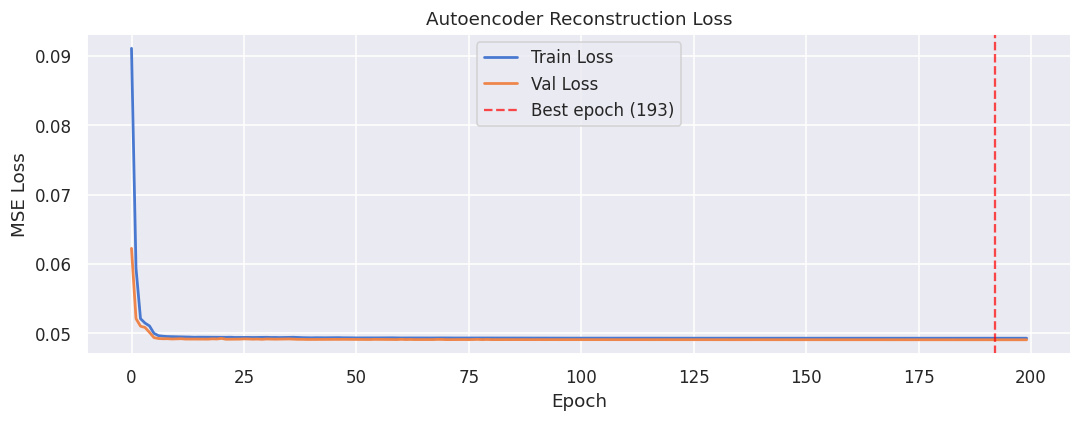

Best validation MSE: 0.049041


In [ ]:
fig, ax = plt.subplots(figsize = (10, 4))
ax.plot(train_losses, label = "Train Loss", linewidth = 1.8)
ax.plot(val_losses, label = "Val Loss", linewidth = 1.8)
ax.axvline(np.argmin(val_losses), color = "red", linestyle = "--", alpha = 0.7, label = f"Best epoch ({np.argmin(val_losses) + 1})")
ax.set(title = "Autoencoder Reconstruction Loss", xlabel = "Epoch", ylabel = "MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best validation MSE: {best_val_loss:.6f}")

## Step 6: Evaluate Reconstruction Quality and Anomaly Thresholding ##

The autoencoder has been trained on healthy data, and should now reconstruct healthy sequences well but produce high reconstruction error for degraded or anomalous windows.

Steps:
1. Compute per-window reconstruction error across all cycles, healthy and degraded
2. Visualize how error evolves over an engine's life (should increase near failure)
3. Set an anomaly detection threshold at `μ + 3σ` of the healthy training distribution

In [ ]:
# Load the best checkpoint

model.load_state_dict(torch.load(best_model_path, map_location = DEVICE))
model.eval()
print("Best model loaded.")

Best model loaded.


In [ ]:
@torch.no_grad()
def get_reconstruction_errors(model, windows_np, batch_size, device):
  """
  Returns the pre-window MSE reconstruction error.
  windows_np: (N, seq_len, n_features)
  """

  errors = []
  ds = WindowDataset(windows_np)
  loader = DataLoader(ds, batch_size = batch_size, shuffle = False)

  for batch in loader:
    batch = batch.to(device)
    recon, _ = model(batch)
    mse = ((recon - batch)**2).mean(dim = (1, 2)) # Per-window MSE
    errors.extend(mse.cpu().numpy())

  return np.array(errors)

In [ ]:
all_healthy_errors = get_reconstruction_errors(model, windows, BATCH_SIZE, DEVICE)

mu_healthy = all_healthy_errors.mean()
sigma_healthy = all_healthy_errors.std()
THRESHOLD = mu_healthy + 3 * sigma_healthy

print(f"Healthy reconstruction error | μ = {mu_healthy:.6f} | σ = {sigma_healthy:.6f}")
print(f"Anomaly threshold (μ + 3σ) | {THRESHOLD:.6f}")

Healthy reconstruction error | μ = 0.009786 | σ = 0.000678
Anomaly threshold (μ + 3σ) | 0.011819


In [ ]:
# Compute reconstruction error over full lifecycle of a few engines
def get_engine_errors(model, df_scaled, engine_id, feature_cols, window_size, stride, device):
  """
  Slide over all cycles of an engine and record per-window errors + cycle.
  """

  grp = df_scaled[df_scaled["unit_id"] == engine_id].sort_values("cycle")
  data = grp[feature_cols].values.astype(np.float32)
  cycles, errors = [], []

  for start in range(0, len(data) - window_size + 1, stride):
    win = torch.tensor(data[start:start + window_size]).unsqueeze(0).to(device)
    recon, _ = model(win)
    err = ((recon - win)**2).mean().item()
    mid_cycle = grp["cycle"].iloc[start + window_size - 1]
    cycles.append(mid_cycle)
    errors.append(err)

  return np.array(cycles), np.array(errors)

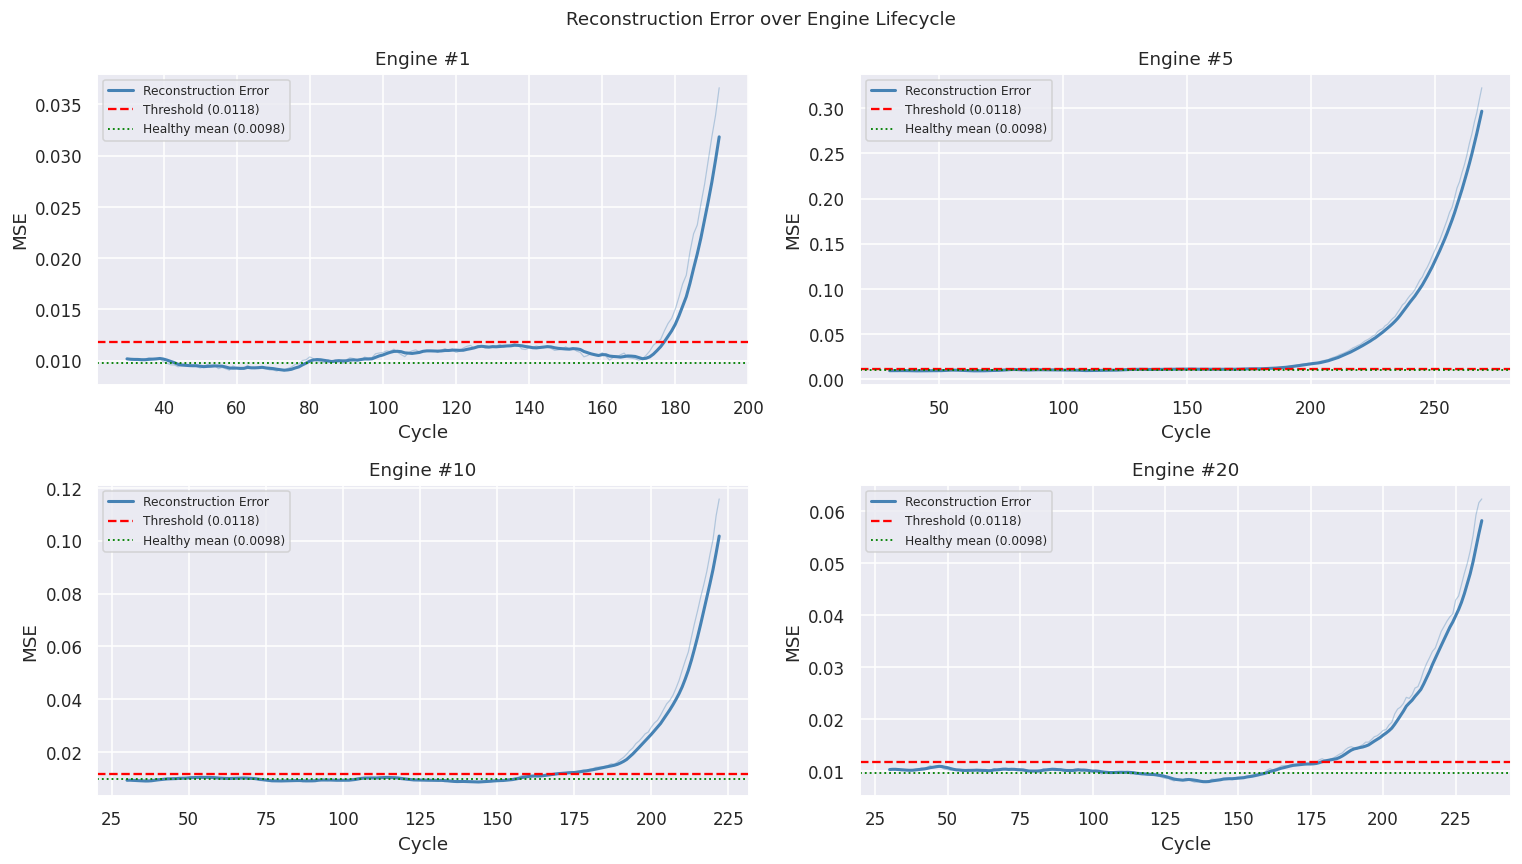

In [ ]:
ENGINES_TO_PLOT = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize = (14, 8))
axes = axes.flatten()

with torch.no_grad():
  for ax, eid in zip(axes, ENGINES_TO_PLOT):
    cyc, errs = get_engine_errors(model, df_scaled, eid, FEATURE_COLS, WINDOW_SIZE, STRIDE, DEVICE)

    # Smooth
    smooth_err = pd.Series(errs).rolling(5, min_periods = 1).mean().values

    ax.plot(cyc, errs, alpha = 0.35, linewidth = 0.8, color = "steelblue")
    ax.plot(cyc, smooth_err, linewidth = 2.0, color = "steelblue", label = "Reconstruction Error")
    ax.axhline(THRESHOLD, color = "red", linestyle = "--", linewidth = 1.5, label = f"Threshold ({THRESHOLD:.4f})")
    ax.axhline(mu_healthy, color = "green", linestyle = ":", linewidth = 1.2, label = f"Healthy mean ({mu_healthy:.4f})")
    ax.set(title = f"Engine #{eid}", xlabel = "Cycle", ylabel = "MSE")
    ax.legend(fontsize = 8)

fig.suptitle("Reconstruction Error over Engine Lifecycle", fontsize = 12)
plt.tight_layout()
plt.show()

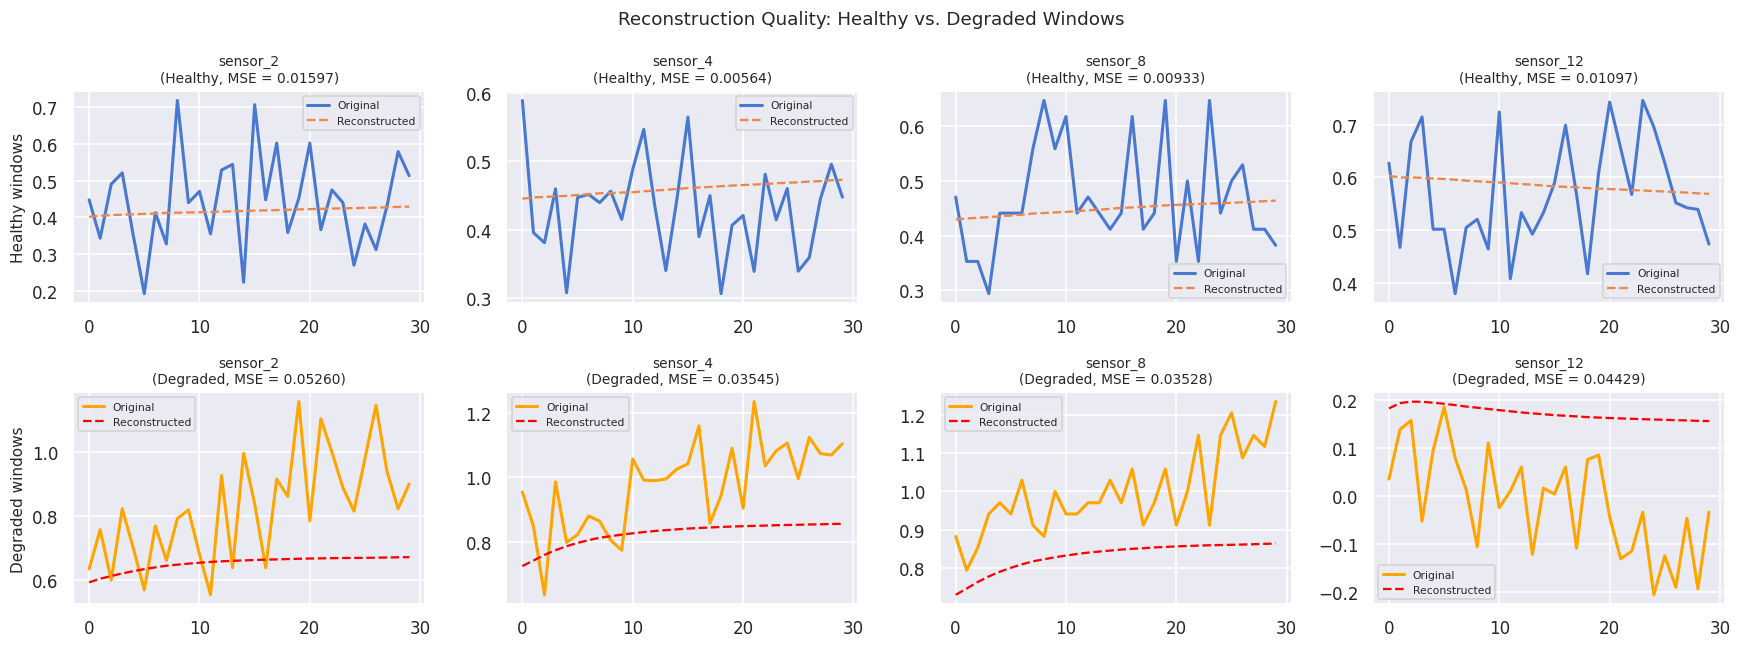

In [ ]:
def get_window_at_cycle(df_scaled, engine_id, cycle_start, feature_cols, window_size):
  grp = df_scaled[df_scaled["unit_id"] == engine_id].sort_values("cycle")
  rows = grp[grp["cycle"] >= cycle_start].head(window_size)

  return rows[feature_cols].values.astype(np.float32)

@torch.no_grad()
def reconstruct(model, window_np, device):
  t = torch.tensor(window_np).unsqueeze(0).to(device)
  recon, z = model(t)

  return recon.squeeze(0).cpu().numpy(), z.cpu().numpy()

engine_id = 1
lifetime = df_scaled[df_scaled["unit_id"] == engine_id]["cycle"].max()

healthy_win = get_window_at_cycle(df_scaled, engine_id, 5, FEATURE_COLS, WINDOW_SIZE)
degraded_win = get_window_at_cycle(df_scaled, engine_id, int(lifetime * 0.85), FEATURE_COLS, WINDOW_SIZE)

recon_h, _ = reconstruct(model, healthy_win, DEVICE)
recon_d, _ = reconstruct(model, degraded_win, DEVICE)

# Four representative sensors to plot
PLOT_SENSORS = [0, 2, 4, 7]
fig, axes = plt.subplots(2, 4, figsize = (16, 6))

for col_idx, s_idx in enumerate(PLOT_SENSORS):
  # Healthy
  ax = axes[0, col_idx]
  ax.plot(healthy_win[:, s_idx], label = "Original", linewidth = 2)
  ax.plot(recon_h[:, s_idx], label = "Reconstructed", linewidth = 1.5, linestyle = "--")
  mse_h = np.mean((healthy_win[:, s_idx] - recon_h[:, s_idx])**2)
  ax.set_title(f"{FEATURE_COLS[s_idx]}\n(Healthy, MSE = {mse_h:.5f})", fontsize = 9)
  ax.legend(fontsize = 7)

  # Degraded
  ax = axes[1, col_idx]
  ax.plot(degraded_win[:, s_idx], label = "Original", linewidth = 2, color = "orange")
  ax.plot(recon_d[:, s_idx], label = "Reconstructed", linewidth = 1.5, linestyle = "--", color = "red")
  mse_d = np.mean((degraded_win[:, s_idx] - recon_d[:, s_idx])**2)
  ax.set_title(f"{FEATURE_COLS[s_idx]}\n(Degraded, MSE = {mse_d:.5f})", fontsize = 9)
  ax.legend(fontsize = 7)

axes[0, 0].set_ylabel("Healthy windows", fontsize = 10)
axes[1, 0].set_ylabel("Degraded windows", fontsize = 10)
fig.suptitle("Reconstruction Quality: Healthy vs. Degraded Windows", fontsize = 12)
plt.tight_layout()
plt.show()

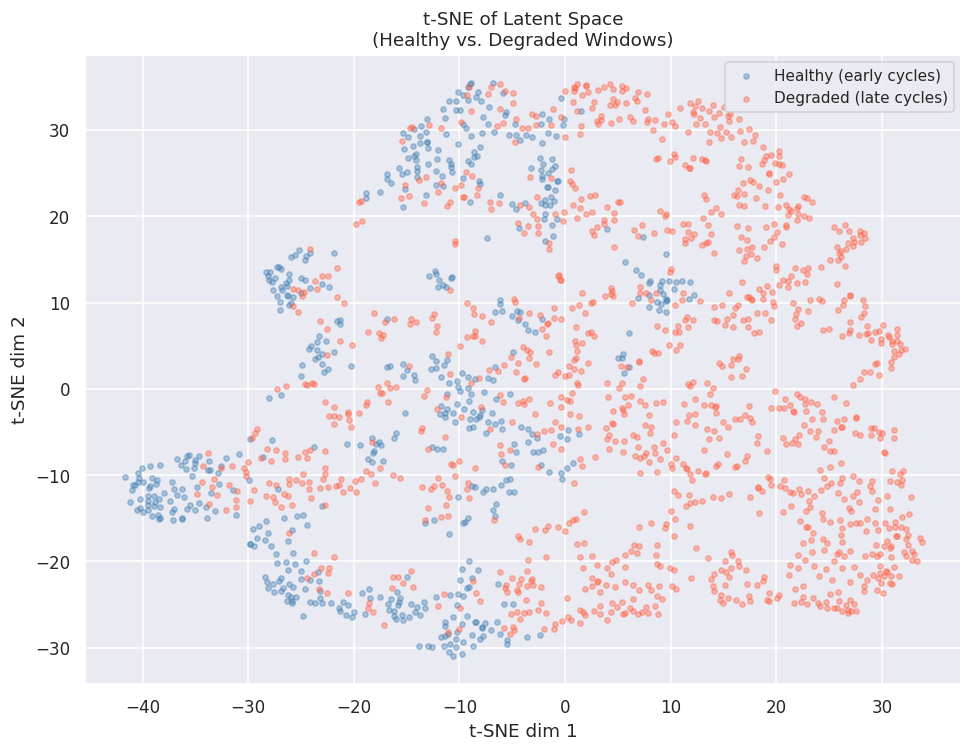


Separation in latent space suggests the encoder has learned meaningful health representations.


In [ ]:
# Latent space visualization (t-SNE)

all_windows_list, all_labels = [], []
for uid, grp in df_scaled.groupby("unit_id"):
  grp = grp.sort_values("cycle").reset_index(drop = True)
  data = grp[FEATURE_COLS].values.astype(np.float32)
  max_cyc = grp["cycle"].max()

  for start in range(0, len(data) - WINDOW_SIZE + 1, 10):
    mid_cycle = grp["cycle"].iloc[start + WINDOW_SIZE - 1]
    label = 0 if mid_cycle <= int(max_cyc * 0.4) else 1 # healthy = 0, degraded = 1
    all_windows_list.append(data[start:start + WINDOW_SIZE])
    all_labels.append(label)

all_windows_np = np.stack(all_windows_list).astype(np.float32)
all_labels_np = np.array(all_labels)

latent_all = []
with torch.no_grad():
  ds_all = WindowDataset(all_windows_np)

  for batch in DataLoader(ds_all, batch_size = 256):
    z = model.encoder(batch.to(DEVICE))
    latent_all.append(z.cpu().numpy())

latent_all = np.concatenate(latent_all, axis = 0)

n_sample = min(3000, len(latent_all))
idx_s = np.random.choice(len(latent_all), n_sample, replace = False)
tsne = TSNE(n_components = 2, random_state = SEED, perplexity = 40, max_iter = 700)
z_2d = tsne.fit_transform(latent_all[idx_s])
labels_2d = all_labels_np[idx_s]

fig, ax = plt.subplots(figsize = (9, 7))
colors = {0: "steelblue", 1: "tomato"}
c_labels = {0: "Healthy (early cycles)", 1: "Degraded (late cycles)"}
for lab in [0, 1]:
  mask = (labels_2d == lab)
  ax.scatter(z_2d[mask, 0], z_2d[mask, 1], c = colors[lab], alpha = 0.4, s = 12, label = c_labels[lab])

ax.set(title = "t-SNE of Latent Space\n(Healthy vs. Degraded Windows)", xlabel = "t-SNE dim 1", ylabel = "t-SNE dim 2")
ax.legend(fontsize = 10)
plt.tight_layout()
plt.show()

print("\nSeparation in latent space suggests the encoder has learned meaningful health representations.")

## Step 7: Save Pretrained Encoder for Part 2 (RUL Prediction) ##

We saved some files needed by Part 2:
1. `best_autoencoder.pt`, the full autoencoder weights
2. `pretrained_encoder.pt`, the encoder-only weights
3. `scaler.pkl`, the fitted MinMaxScaler used to scale features
4. `pretraining_config.json`, hyperparameters for reproducibility

In [ ]:
# Save encoder weights
encoder_path = "/content/pretrained_encoder.pt"
torch.save(model.encoder.state_dict(), encoder_path)
print(f"Encoder weights saved to {encoder_path}")

# Save configuration
config = {
    "dataset": "C-MAPSS FD001",
    "feature_cols": FEATURE_COLS,
    "n_features": N_FEATURES,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "healthy_frac": HEALTHY_FRAC,
    "hidden_dim": HIDDEN_DIM,
    "latent_dim": LATENT_DIM,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "best_val_composite_loss": float(best_val_loss),
    "best_val_mse": float(mu_healthy),
    "anomaly_threshold": float(THRESHOLD),
    "healthy_mean_mse": float(mu_healthy),
    "healthy_std_mse": float(sigma_healthy)
}
config_path = "/content/pretraining_config.json"
with open(config_path, "w") as f:
  json.dump(config, f, indent = 2)
print(f"Config saved to {config_path}")

print("\nConfig summary: ")
print(json.dumps(config, indent = 2))

Encoder weights saved to /content/pretrained_encoder.pt
Config saved to /content/pretraining_config.json

Config summary: 
{
  "dataset": "C-MAPSS FD001",
  "feature_cols": [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
  ],
  "n_features": 14,
  "window_size": 30,
  "stride": 1,
  "healthy_frac": 0.4,
  "hidden_dim": 128,
  "latent_dim": 64,
  "num_layers": 2,
  "dropout": 0.2,
  "best_val_composite_loss": 0.04904127818353502,
  "best_val_mse": 0.009785975329577923,
  "anomaly_threshold": 0.011818692088127136,
  "healthy_mean_mse": 0.009785975329577923,
  "healthy_std_mse": 0.0006775724468752742
}


In [ ]:
# Download artifacts to local machine
for path in [best_model_path, encoder_path, "/content/scaler.pkl", config_path]:
  files.download(path)
  print(f"Downloading {path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Summary #

What was learned...
* The encoder maps healthy machine behavior to a compact latent space
* Reconstruction error increases as machines degrade, providing an anomaly detection signal
* The t-SNE plot confirms that healthy and degraded windows are separable in latent space

Part 2: RUL Prediction with Uncertainty Estimation
* Load `pretrained_encoder.pt` weights to initialize the LSTM encoder
* Fine-tune with RUL labels and Monte Carlo Dropout for uncertainty quantification
* Add SHAP-based explainability for sensor attribution